ACC shape: (222395, 5) dtype: float64
GYR shape: (222395, 5) dtype: float64

ACC first rows:
 [[ 4.05000000e+03  1.56279087e+12 -7.02459240e+00 -1.67411880e+00
   5.97796900e+00]
 [ 4.05000000e+03  1.56279087e+12 -6.99345730e+00 -3.42487800e-01
   5.82229300e+00]
 [ 4.05000000e+03  1.56279087e+12 -6.81862070e+00  1.36516120e+00
   6.18394100e+00]
 [ 4.05000000e+03  1.56279087e+12 -6.86891650e+00  2.41417980e+00
   6.64378450e+00]
 [ 4.05100000e+03  1.56279087e+12 -7.44372100e+00  1.96631110e+00
   6.66054960e+00]]

GYR first rows:
 [[ 4.05000000e+03  1.56279087e+12  7.53494200e-01 -1.45987000e-01
   1.14873740e+00]
 [ 4.05000000e+03  1.56279087e+12  1.09191330e+00 -3.52459400e-01
   1.00823860e+00]
 [ 4.05000000e+03  1.56279087e+12  1.01127920e+00 -4.03772060e-01
   9.61812800e-01]
 [ 4.05000000e+03  1.56279087e+12  7.77928800e-01 -2.93816360e-01
   9.44708600e-01]
 [ 4.05100000e+03  1.56279087e+12  4.43174780e-01 -1.08113380e-01
   9.98464700e-01]]

Extracted shapes:
ACC xyz: (222395,

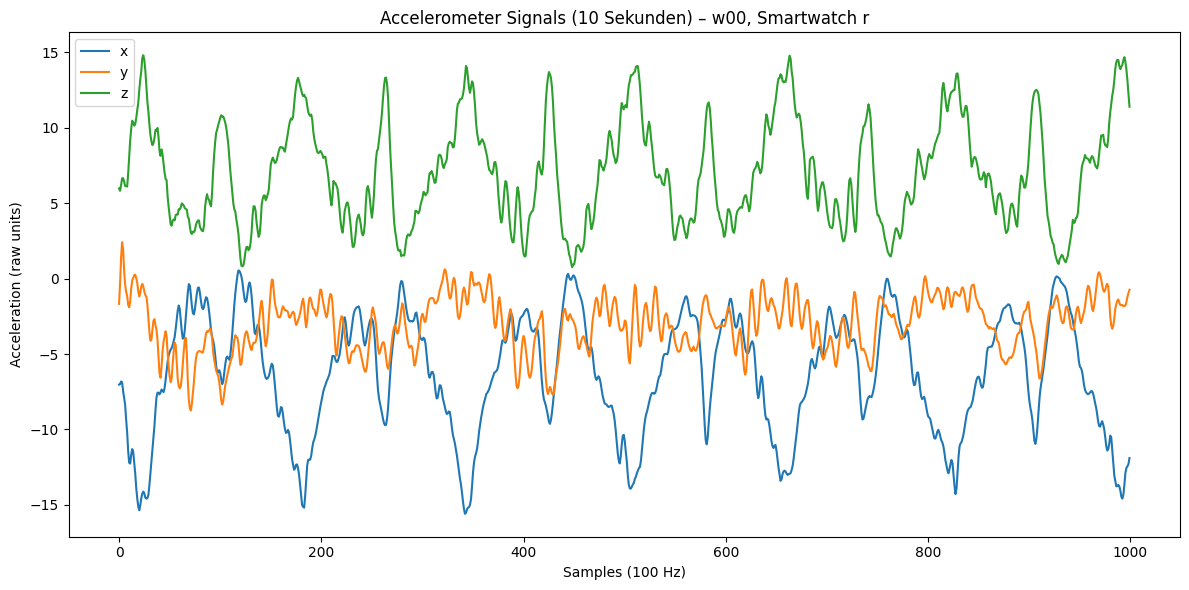

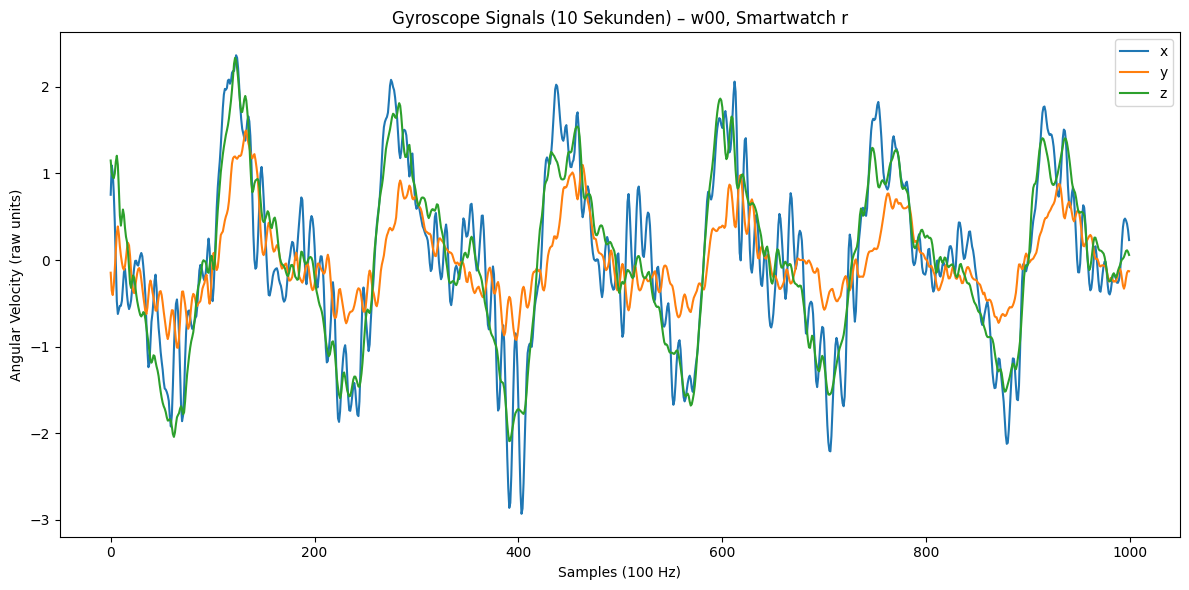

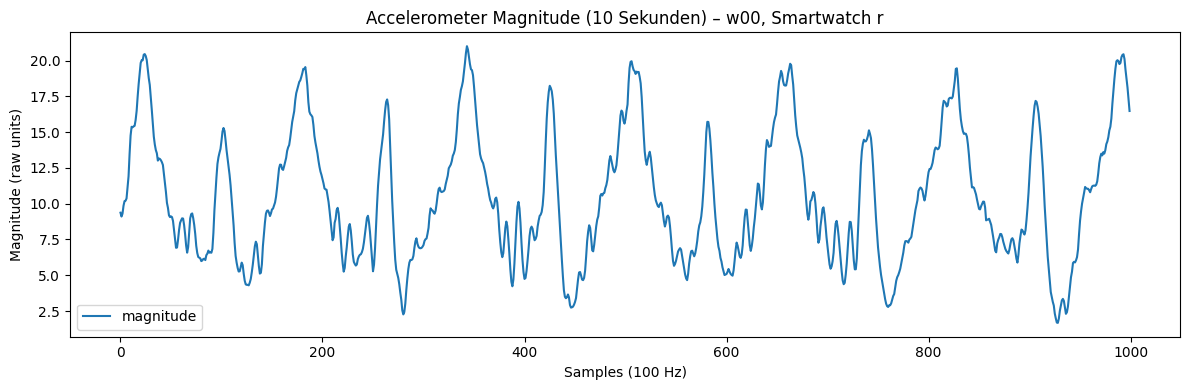

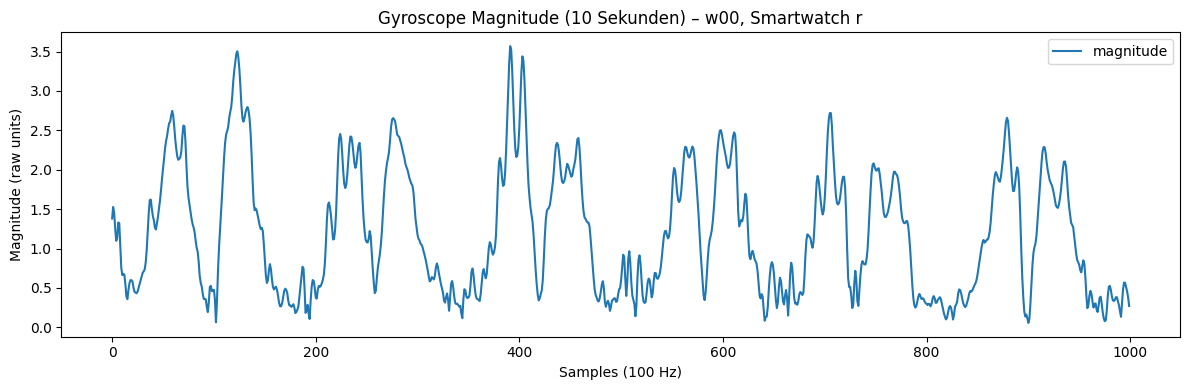

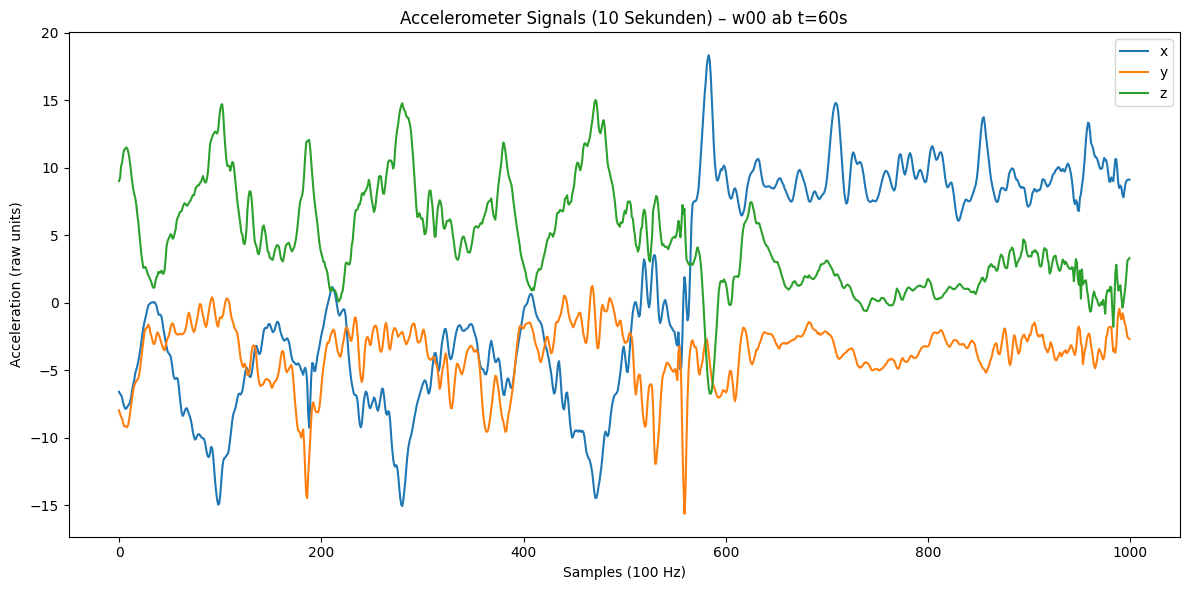

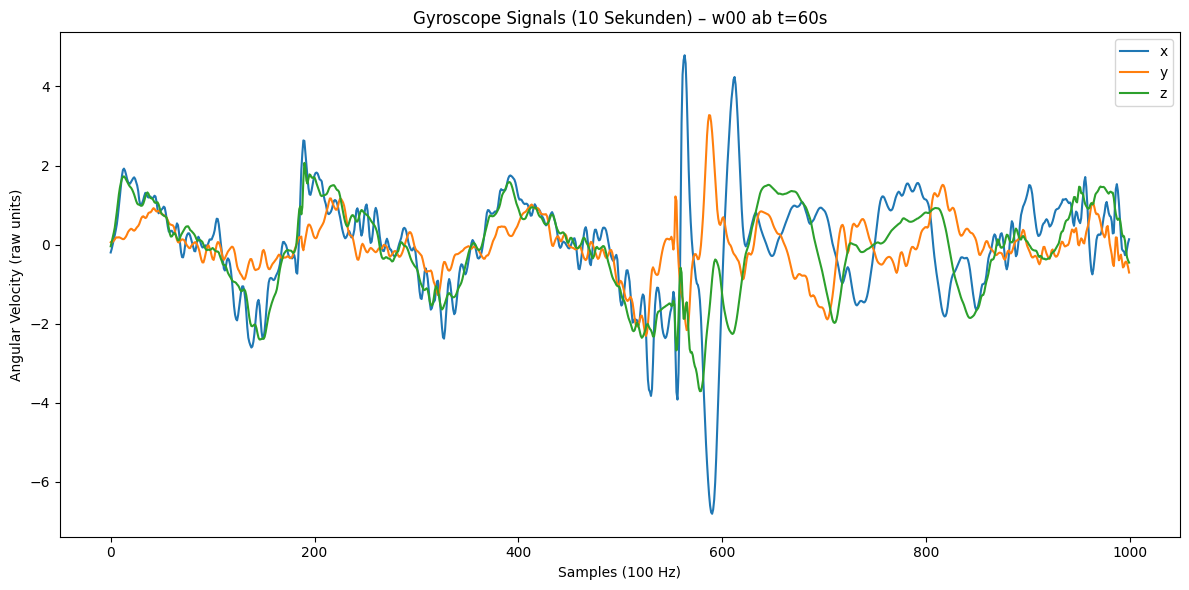

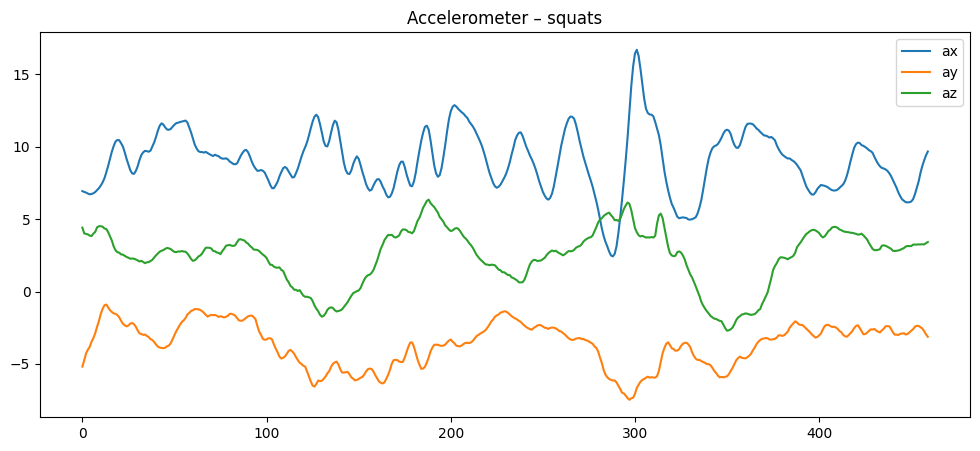

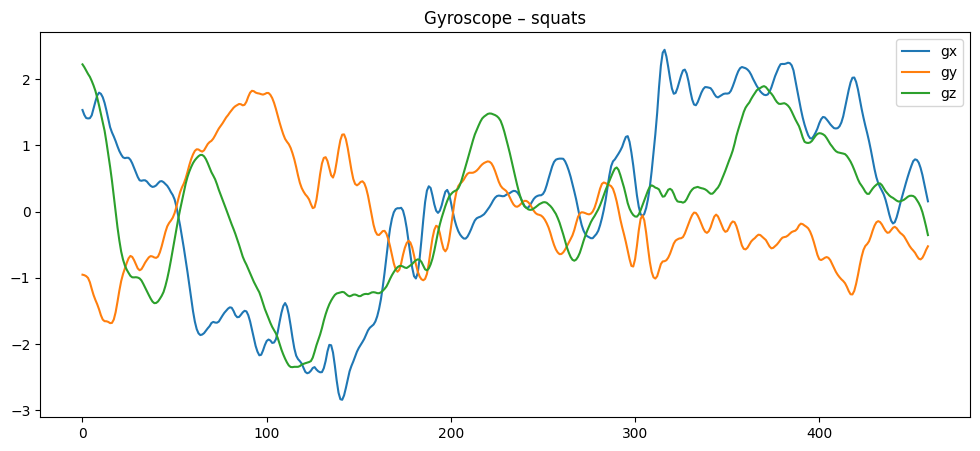

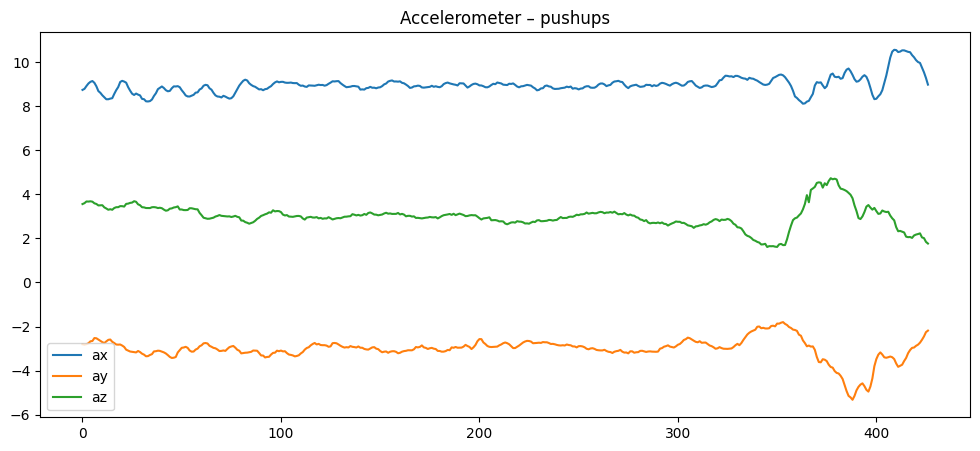

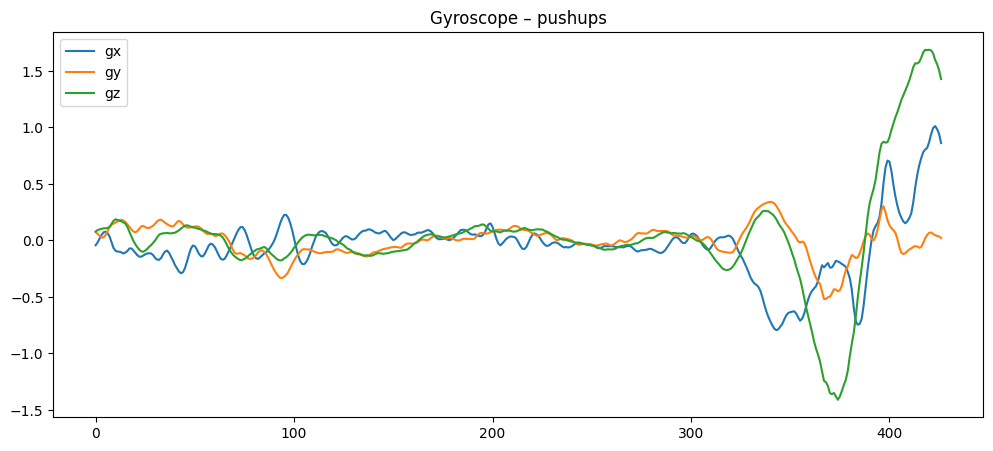


Nächster Schritt:
- Such dir 2–3 Zeitpunkte (start-Index), wo du klare Bewegung siehst,
  und mach davon Plots (z.B. start=30000, 60000, 90000).
- Notiere dann in Markdown:
  • Welche Achse dominiert?
  • Siehst du periodische Peaks?
  • Gibt es Rauschen/Übergänge?



In [ ]:
# ============================================
# 00_data_exploration.ipynb  (MM-Fit)
# Kapitel: 2.3 Explorative Analyse
# ============================================

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# -------------------------------
# 1) Konfiguration
# -------------------------------

SESSION = "w00"
DATA_DIR = "./mm-fit/w00"  # falls deine Dateien in einem Unterordner liegen: z.B. "./mmfit"
SIDE = "r"      # r = rechte Hand (right)

ACC_FILE = os.path.join(DATA_DIR, f"{SESSION}_sw_{SIDE}_acc.npy")
GYR_FILE = os.path.join(DATA_DIR, f"{SESSION}_sw_{SIDE}_gyr.npy")

FS = 100  # Samplingrate (Hz)
PLOT_SECONDS = 10
N = FS * PLOT_SECONDS

labels = pd.read_csv(
    "./mm-fit/w00/w00_labels.csv",
    header=None,
    names=["start", "end", "reps", "exercise"]
)

labels.head()

# Optional: Plots als PNG speichern (für deine Thesis)
SAVE_PLOTS = False
PLOTS_DIR = os.path.join(DATA_DIR, "plots")
os.makedirs(PLOTS_DIR, exist_ok=True)


# -------------------------------
# 2) Daten laden
# -------------------------------

acc = np.load(ACC_FILE)
gyr = np.load(GYR_FILE)

print("ACC shape:", acc.shape, "dtype:", acc.dtype)
print("GYR shape:", gyr.shape, "dtype:", gyr.dtype)

print("\nACC first rows:\n", acc[:5])
print("\nGYR first rows:\n", gyr[:5])




# -------------------------------
# 3) Spalten-Interpretation prüfen
# -------------------------------
# Du hast (T,5). In deinem Screenshot war:
# [ time_like, timestamp_like, x, y, z ]
#
# Wir machen es robust:
# - Wenn 5 Spalten: nehmen wir die letzten 3 als xyz
# - Wenn 3 Spalten: direkt xyz
# - Wenn 4 Spalten: häufig [timestamp, x, y, z] -> nehmen wir Spalten 1:4

def extract_xyz(arr: np.ndarray) -> np.ndarray:
    if arr.ndim != 2:
        raise ValueError(f"Expected 2D array, got shape {arr.shape}")
    if arr.shape[1] == 3:
        return arr
    if arr.shape[1] == 4:
        return arr[:, 1:4]
    if arr.shape[1] == 5:
        return arr[:, 2:5]
    raise ValueError(f"Unexpected number of columns: {arr.shape[1]}")

acc_xyz = extract_xyz(acc)
gyr_xyz = extract_xyz(gyr)

print("\nExtracted shapes:")
print("ACC xyz:", acc_xyz.shape)
print("GYR xyz:", gyr_xyz.shape)

print("\nValue ranges (sanity check):")
print("ACC xyz min/max:", float(acc_xyz.min()), float(acc_xyz.max()))
print("GYR xyz min/max:", float(gyr_xyz.min()), float(gyr_xyz.max()))


# -------------------------------
# 4) Hilfsfunktionen fürs Plotten
# -------------------------------

def plot_xyz(xyz: np.ndarray, title: str, y_label: str, start: int = 0, n: int = 1000, save_path: str | None = None):
    end = min(start + n, xyz.shape[0])
    seg = xyz[start:end]

    plt.figure(figsize=(12, 6))
    plt.plot(seg[:, 0], label="x")
    plt.plot(seg[:, 1], label="y")
    plt.plot(seg[:, 2], label="z")

    plt.title(title)
    plt.xlabel(f"Samples ({FS} Hz)")
    plt.ylabel(y_label)
    plt.legend()
    plt.tight_layout()

    if save_path:
        plt.savefig(save_path, dpi=200)
    plt.show()


def plot_magnitude(xyz: np.ndarray, title: str, y_label: str, start: int = 0, n: int = 1000, save_path: str | None = None):
    end = min(start + n, xyz.shape[0])
    seg = xyz[start:end]
    mag = np.sqrt((seg ** 2).sum(axis=1))

    plt.figure(figsize=(12, 4))
    plt.plot(mag, label="magnitude")
    plt.title(title)
    plt.xlabel(f"Samples ({FS} Hz)")
    plt.ylabel(y_label)
    plt.legend()
    plt.tight_layout()

    if save_path:
        plt.savefig(save_path, dpi=200)
    plt.show()


# -------------------------------
# 5) Plot: kurzer Ausschnitt (z.B. erste 10 Sekunden)
# -------------------------------

start = 0

acc_path = os.path.join(PLOTS_DIR, f"{SESSION}_acc_{PLOT_SECONDS}s.png") if SAVE_PLOTS else None
gyr_path = os.path.join(PLOTS_DIR, f"{SESSION}_gyr_{PLOT_SECONDS}s.png") if SAVE_PLOTS else None

plot_xyz(
    acc_xyz,
    title=f"Accelerometer Signals ({PLOT_SECONDS} Sekunden) – {SESSION}, Smartwatch {SIDE}",
    y_label="Acceleration (raw units)",
    start=start,
    n=N,
    save_path=acc_path
)

plot_xyz(
    gyr_xyz,
    title=f"Gyroscope Signals ({PLOT_SECONDS} Sekunden) – {SESSION}, Smartwatch {SIDE}",
    y_label="Angular Velocity (raw units)",
    start=start,
    n=N,
    save_path=gyr_path
)


# -------------------------------
# 6) Optional: Magnitude (hilft Muster/Peaks leichter zu sehen)
# -------------------------------

acc_mag_path = os.path.join(PLOTS_DIR, f"{SESSION}_acc_mag_{PLOT_SECONDS}s.png") if SAVE_PLOTS else None
gyr_mag_path = os.path.join(PLOTS_DIR, f"{SESSION}_gyr_mag_{PLOT_SECONDS}s.png") if SAVE_PLOTS else None

plot_magnitude(
    acc_xyz,
    title=f"Accelerometer Magnitude ({PLOT_SECONDS} Sekunden) – {SESSION}, Smartwatch {SIDE}",
    y_label="Magnitude (raw units)",
    start=start,
    n=N,
    save_path=acc_mag_path
)

plot_magnitude(
    gyr_xyz,
    title=f"Gyroscope Magnitude ({PLOT_SECONDS} Sekunden) – {SESSION}, Smartwatch {SIDE}",
    y_label="Magnitude (raw units)",
    start=start,
    n=N,
    save_path=gyr_mag_path
)


# -------------------------------
# 7) Optional: anderer Ausschnitt plotten
# (hilft, wenn am Anfang evtl. Pause ist)
# -------------------------------

# Beispiel: 60 Sekunden rein springen
start_2 = FS * 60

plot_xyz(
    acc_xyz,
    title=f"Accelerometer Signals ({PLOT_SECONDS} Sekunden) – {SESSION} ab t=60s",
    y_label="Acceleration (raw units)",
    start=start_2,
    n=N,
    save_path=None
)

plot_xyz(
    gyr_xyz,
    title=f"Gyroscope Signals ({PLOT_SECONDS} Sekunden) – {SESSION} ab t=60s",
    y_label="Angular Velocity (raw units)",
    start=start_2,
    n=N,
    save_path=None
)


# funktion um eine übung zu plotten

def plot_exercise_segment(acc_xyz, gyr_xyz, start, end, exercise_name):
    segment_acc = acc_xyz[start:end]
    segment_gyr = gyr_xyz[start:end]

    plt.figure(figsize=(12,5))
    plt.plot(segment_acc[:,0], label="ax")
    plt.plot(segment_acc[:,1], label="ay")
    plt.plot(segment_acc[:,2], label="az")
    plt.title(f"Accelerometer – {exercise_name}")
    plt.legend()
    plt.show()

    plt.figure(figsize=(12,5))
    plt.plot(segment_gyr[:,0], label="gx")
    plt.plot(segment_gyr[:,1], label="gy")
    plt.plot(segment_gyr[:,2], label="gz")
    plt.title(f"Gyroscope – {exercise_name}")
    plt.legend()
    plt.show()


#squats und pushups plotten
row = labels[labels["exercise"] == "squats"].iloc[0]
plot_exercise_segment(acc_xyz, gyr_xyz, row.start, row.end, "squats")

row = labels[labels["exercise"] == "pushups"].iloc[0]
plot_exercise_segment(acc_xyz, gyr_xyz, row.start, row.end, "pushups")


# -------------------------------
# 8) Markdown-Hinweis (du schreibst hier im Notebook deine Beobachtungen)
# -------------------------------
print("""
Nächster Schritt:
- Such dir 2–3 Zeitpunkte (start-Index), wo du klare Bewegung siehst,
  und mach davon Plots (z.B. start=30000, 60000, 90000).
- Notiere dann in Markdown:
  • Welche Achse dominiert?
  • Siehst du periodische Peaks?
  • Gibt es Rauschen/Übergänge?
""")